In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import os
files = os.listdir('/content/drive/MyDrive')
print(files)

['archive.zip', 'Colab Notebooks']


In [4]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Done unzipping")

Done unzipping


In [5]:
import os

for split in ['train', 'valid', 'test']:
    for label in ['Bleached', 'Healthy']:
        path = f'/content/data/{split}/{label}'
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"{split}/{label}: {count} images")
        else:
            print(f"{split}/{label}: NOT FOUND")

train/Bleached: NOT FOUND
train/Healthy: NOT FOUND
valid/Bleached: NOT FOUND
valid/Healthy: NOT FOUND
test/Bleached: NOT FOUND
test/Healthy: NOT FOUND


In [6]:
import os

for item in os.listdir('/content/data'):
    print(item)

Coral Reef Images


In [8]:
import os

for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for d in dirs:
            print(f'{indent}  {d}/')

data/
  Coral Reef Images/
  Coral Reef Images/
    test/
    train/
    valid/
    test/
      Bleached/
      Healthy/
      Bleached/
      Healthy/
    train/
      Bleached/
      Healthy/
      Bleached/
      Healthy/
    valid/
      Bleached/
      Healthy/
      Bleached/
      Healthy/


In [11]:
import os

data_dir = '/content/data/Coral Reef Images'

for split in ['train', 'valid', 'test']:
    for label in ['Bleached', 'Healthy']:
        path = f'{data_dir}/{split}/{label}'
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} images")

train/Bleached: 4980 images
train/Healthy: 4682 images
valid/Bleached: 240 images
valid/Healthy: 223 images
test/Bleached: 135 images
test/Healthy: 122 images


In [12]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = '/content/data/Coral Reef Images'

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
val_data = datasets.ImageFolder(data_dir + '/valid', transform=val_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Classes: {train_data.classes}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Classes: ['Bleached', 'Healthy']
Training batches: 302
Validation batches: 15


In [13]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")

# Load pretrained MobileNetV2
model = models.mobilenet_v2(pretrained=True)

# Freeze base layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier head for binary classification
model.classifier[1] = nn.Linear(model.last_channel, 2)

model = model.to(device)
print("Model ready")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 84.2MB/s]


Model ready


In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[1].parameters(), lr=0.001)

def train_model(model, epochs=5):
    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100 * correct / total

        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100 * val_correct / val_total
        print(f"Epoch {epoch+1}/5 | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%")

train_model(model, epochs=5)

Epoch 1/5 | Train Acc: 89.4% | Val Acc: 90.1%
Epoch 2/5 | Train Acc: 92.1% | Val Acc: 88.6%
Epoch 3/5 | Train Acc: 93.1% | Val Acc: 88.6%
Epoch 4/5 | Train Acc: 93.3% | Val Acc: 90.9%
Epoch 5/5 | Train Acc: 93.0% | Val Acc: 92.0%


In [15]:
import os
os.makedirs('/content/drive/MyDrive/CoralWatch', exist_ok=True)

torch.save(model.state_dict(), '/content/drive/MyDrive/CoralWatch/model.pth')
print("Model saved to Google Drive")

Model saved to Google Drive


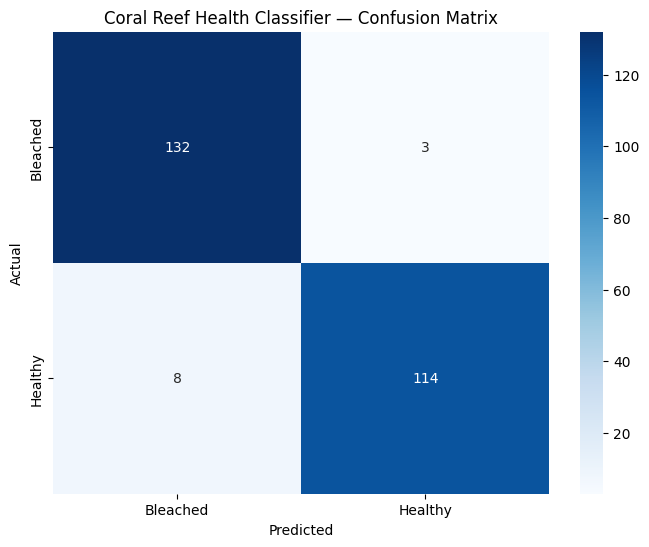

              precision    recall  f1-score   support

    Bleached       0.94      0.98      0.96       135
     Healthy       0.97      0.93      0.95       122

    accuracy                           0.96       257
   macro avg       0.96      0.96      0.96       257
weighted avg       0.96      0.96      0.96       257



In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Bleached', 'Healthy'],
            yticklabels=['Bleached', 'Healthy'],
            cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Coral Reef Health Classifier — Confusion Matrix')
plt.show()

# Full report
print(classification_report(all_labels, all_preds,
                           target_names=['Bleached', 'Healthy']))